## <font color = '#6495ED'>  ______________________ **Text Mining - Stock Sentiment** _____________________
#### _______________________________________________Academic Year: 2024/2025 _____________________________________________

<div style="text-align: center;">
    <strong>Group 31</strong>
    <table style="margin: 0 auto; border-collapse: collapse; border: 1px solid black;">
        <tr>
            <th style="border: 1px solid white; padding: 8px;">Name</th>
            <th style="border: 1px solid white; padding: 8px;">Student ID</th>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">David Cascão</td>
            <td style="border: 1px solid white; padding: 8px;">20240851</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Elcano Gaspar</td>
            <td style="border: 1px solid white; padding: 8px;">20241021</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Jorge Cordeiro</td>
            <td style="border: 1px solid white; padding: 8px;">20240594</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Rui Reis</td>
            <td style="border: 1px solid white; padding: 8px;">20240854</td>
        </tr>
    </table>
</div>

### <font color = '#6495ED'>  **1. Libraries, Functions, Configuration and Datasets** </font>

#### <font color = '#6495ED'> **1.1. Import the Needed Libraries** </font>

In [1]:
#Data management
import numpy as np
import pandas as pd
from scipy.stats import mode
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from collections import Counter

#models
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

#Preprocessing
from tqdm import tqdm
import re
import nltk

#Visualization
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

from tqdm import tqdm

/home/20230380/.conda/envs/david_dah/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### <font color = '#6495ED'> **1.2. Setup and Configuration** </font>

In [2]:
# Download required NLTK resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
pd.set_option('display.max_colwidth', None)

# Set seaborn style and matplotlib defaults
sns.set(style="whitegrid", color_codes= "#152645", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.dpi'] = 100

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/20230380/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/20230380/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/20230380/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


#### <font color = '#6495ED'>**1.3. Load the Dataset** </font>

In [3]:
train = pd.read_csv("/home/20230380/Cifo/train.csv")


### <font color = '#6495ED'> **3. Preprocessing** </font>

#### <font color = '#6495ED'> **3.1. Corpus split** </font>

In [4]:
val, train = train_test_split(train, test_size=0.2,random_state=42,stratify=train["label"])

#### <font color = '#6495ED'> **3.2. Data Cleaning for Generative Models** </font>

In [5]:
def clean_for_generative_models(text_list):
    cleaned = []
    for text in tqdm(text_list, desc="Cleaning texts"):
        text = re.sub(r"http\S+|www\S+|https\S+", "<URL>", text)
        text = re.sub(r"@\w+", "<USER>", text)
        text = re.sub(r"#(\w+)", r"\1", text)
        text = re.sub(r"\s+", " ", text).strip()
        cleaned.append(text)
    return cleaned

train["clean_text"] = clean_for_generative_models(train["text"].tolist())

Cleaning texts: 100%|██████████| 1909/1909 [00:00<00:00, 147207.79it/s]


In [6]:
def classify_with_model(prompt, generator):
    response = generator(prompt, max_new_tokens=10, do_sample=False,return_full_text=False)[0]["generated_text"]
    matches = re.findall(r"\b[012]\b", response)
    return int(matches[-1]) if matches else 2

##### <font color = '#6495ED'> **3.3.1. Few-Shot  Prompt Classification** </font>

In [ ]:
few_shot_examples = [
    ("Deutsche Bank sues over $1.6 billion in claims against Bernard Madoff’s bankrupt investment advisory business", 0),
    ("Hedge Funds Are Dumping Ocwen Financial Corporation (OCN)",0),
    ("$BLRX - BioLineRx up big ahead of key data readout",1),
    ("Axcelis Technologies stock price target raised to $32 from $24 at Benchmark", 1),
    ("Web inventor has an ambitious plan to take back the net", 2),
    ("Iran joins Russia and China in joint naval exercises beginning Friday",2)
]

def few_shot_prompt(text, examples=few_shot_examples):
    prompt = """You are a financial sentiment classifier.

Here are some context about what a tweet should have for each class

•⁠ **Bearish (0):** Indicates a negative outlook or expectation of decline for a stock, company, or the overall market. Look for keywords related to price drops, downgrades, losses, selling, or negative news.

•⁠ **Bullish (1):** Indicates a positive outlook or expectation of rise for a stock, company, or the overall market. Look for keywords related to gains, upgrades, strong performance, buying, or positive news.

•⁠ **Neutral (2):** Indicates a lack of strong positive or negative sentiment, or expresses factual information without a clear market bias. This includes general news that doesn't imply a clear direction for the stock or market.

Here are some examples:
"""
    for ex_text, ex_label in examples:
        prompt += f'Text: "{ex_text}"\nAnswer: {ex_label}\n\n'

    prompt += f'Text: "{text}"\nAnswer:'
    return prompt

In [ ]:
train

#### <font color = '#6495ED'> **3.3. Generative Models for Classification** </font>

##### <font color = '#6495ED'> **3.3.1 OpenChat 3.5** </font>

In [ ]:
tokenizer_openchat = AutoTokenizer.from_pretrained("openchat/openchat-3.5-0106")
model_openchat = AutoModelForCausalLM.from_pretrained("openchat/openchat-3.5-0106", torch_dtype=torch.float16, device_map="auto")
generator_openchat = pipeline("text-generation", model=model_openchat, tokenizer=tokenizer_openchat, do_sample=False, return_full_text=False)

openchat_preds = []
for text in tqdm(train["clean_text"], desc="OpenChat Classifying"):
    prompt = few_shot_prompt(text)
    openchat_preds.append(classify_with_model(prompt, generator_openchat))
train["openchat_preds"] = openchat_preds

del model_openchat, tokenizer_openchat, generator_openchat
torch.cuda.empty_cache()

OpenChat Classifying: 100%|██████████| 1909/1909 [10:52<00:00,  2.93it/s]


In [9]:
print(classification_report(train["label"], train["openchat_preds"], digits=3))

              precision    recall  f1-score   support

           0      0.560     0.875     0.683       288
           1      0.623     0.894     0.734       385
           2      0.931     0.683     0.788      1236

    accuracy                          0.754      1909
   macro avg      0.705     0.817     0.735      1909
weighted avg      0.813     0.754     0.761      1909



##### <font color = '#6495ED'> **3.3.2 Microsoft phi 3 mini** </font>

In [10]:
tokenizer_phi3 = AutoTokenizer.from_pretrained("microsoft/phi-3-mini-4k-instruct")
model_phi3 = AutoModelForCausalLM.from_pretrained("microsoft/phi-3-mini-4k-instruct", torch_dtype=torch.float16, device_map="auto")
generator_phi3 = pipeline("text-generation", model=model_phi3, tokenizer=tokenizer_phi3, do_sample=False, return_full_text=False)

phi3_preds = []
for text in tqdm(train["clean_text"], desc="Phi-3 Classifying"):
    prompt = few_shot_prompt(text)
    phi3_preds.append(classify_with_model(prompt, generator_phi3))
train["phi3_preds"] = phi3_preds

del model_phi3, tokenizer_phi3, generator_phi3
torch.cuda.empty_cache()

Phi-3 Classifying: 100%|██████████| 1909/1909 [08:48<00:00,  3.61it/s]


##### <font color = '#6495ED'> **3.3.4 HuggingFace Zephyr 7b beta** </font>

In [11]:
tokenizer_zephyr = AutoTokenizer.from_pretrained("HuggingFaceH4/zephyr-7b-beta")
model_zephyr = AutoModelForCausalLM.from_pretrained("HuggingFaceH4/zephyr-7b-beta", torch_dtype=torch.float16, device_map="auto")
generator_zephyr = pipeline("text-generation", model=model_zephyr, tokenizer=tokenizer_zephyr, do_sample=False, return_full_text=False)

zephyr_preds = []
for text in tqdm(train["clean_text"], desc="Zephyr Classifying"):
    prompt = few_shot_prompt(text)
    zephyr_preds.append(classify_with_model(prompt, generator_zephyr))
train["zephyr_preds"] = zephyr_preds

del model_zephyr, tokenizer_zephyr, generator_zephyr
torch.cuda.empty_cache()

Zephyr Classifying: 100%|██████████| 1909/1909 [11:11<00:00,  2.84it/s]


##### <font color = '#6495ED'> **3.3.5 Yi 6B** </font>

In [12]:
tokenizer_yi = AutoTokenizer.from_pretrained("01-ai/Yi-6B-Chat")
model_yi = AutoModelForCausalLM.from_pretrained("01-ai/Yi-6B-Chat", torch_dtype=torch.float16, device_map="auto")
generator_yi = pipeline("text-generation", model=model_yi, tokenizer=tokenizer_yi, do_sample=False, return_full_text=False)

yi_preds = []
for text in tqdm(train["clean_text"], desc="Yi Chat Classifying"):
    prompt = few_shot_prompt(text)
    yi_preds.append(classify_with_model(prompt, generator_yi))
train["yi_preds"] = yi_preds

del model_yi, tokenizer_yi, generator_yi
torch.cuda.empty_cache()

Yi Chat Classifying: 100%|██████████| 1909/1909 [09:21<00:00,  3.40it/s]


##### <font color = '#6495ED'> **3.3.6 Berkeley Starling 7B** </font>

In [13]:
tokenizer_starling = AutoTokenizer.from_pretrained("berkeley-nest/Starling-LM-7B-alpha")
model_starling = AutoModelForCausalLM.from_pretrained("berkeley-nest/Starling-LM-7B-alpha", torch_dtype=torch.float16, device_map="auto")
generator_starling = pipeline("text-generation", model=model_starling, tokenizer=tokenizer_starling, do_sample=False, return_full_text=False)

starling_preds = []
for text in tqdm(train["clean_text"], desc="Starling LM Classifying"):
    prompt = few_shot_prompt(text)
    starling_preds.append(classify_with_model(prompt, generator_starling))
train["starling_preds"] = starling_preds

del model_starling, tokenizer_starling, generator_starling
torch.cuda.empty_cache()

Starling LM Classifying: 100%|██████████| 1909/1909 [10:22<00:00,  3.07it/s]


##### <font color = '#6495ED'> **3.4 Classification Report** </font>

In [14]:
train.to_csv("/home/20230380/Cifo/train_with_preds_prompt_before.csv",index=False)

from sklearn.metrics import classification_report

y_true = train["label"]

for col in train.columns:
    if col.endswith("_preds"):
        print(f"\nClassification Report for {col}:")
        print(classification_report(y_true, train[col], digits=3))



Classification Report for openchat_preds:
              precision    recall  f1-score   support

           0      0.560     0.875     0.683       288
           1      0.623     0.894     0.734       385
           2      0.931     0.683     0.788      1236

    accuracy                          0.754      1909
   macro avg      0.705     0.817     0.735      1909
weighted avg      0.813     0.754     0.761      1909


Classification Report for phi3_preds:
              precision    recall  f1-score   support

           0      0.605     0.722     0.658       288
           1      0.713     0.756     0.734       385
           2      0.861     0.806     0.832      1236

    accuracy                          0.783      1909
   macro avg      0.726     0.761     0.742      1909
weighted avg      0.792     0.783     0.786      1909


Classification Report for zephyr_preds:
              precision    recall  f1-score   support

           0      0.638     0.660     0.648       288
      

##### <font color = '#6495ED'> **3.5 Confusion Matrices** </font>


Confusion Matrix for openchat_preds:


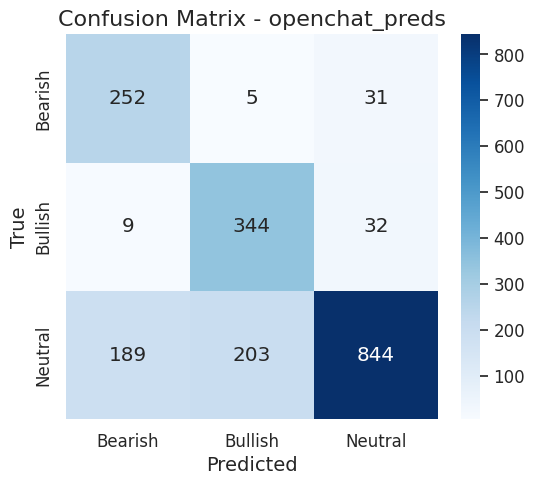


Confusion Matrix for phi3_preds:


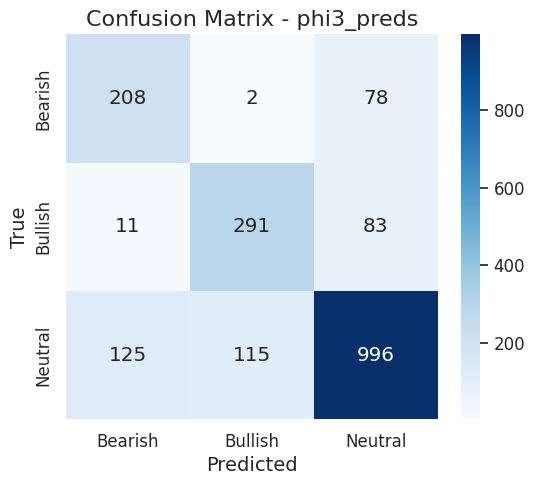


Confusion Matrix for zephyr_preds:


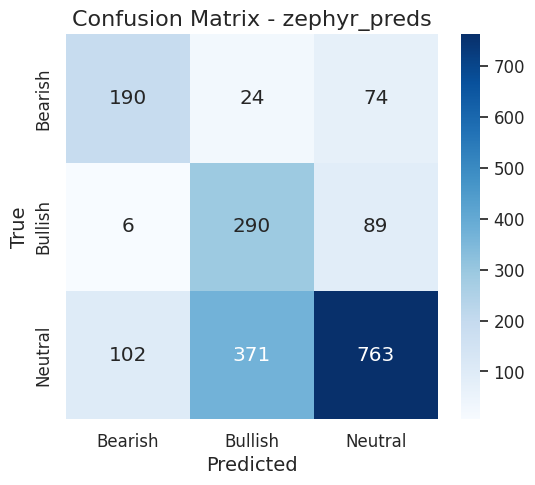


Confusion Matrix for yi_preds:


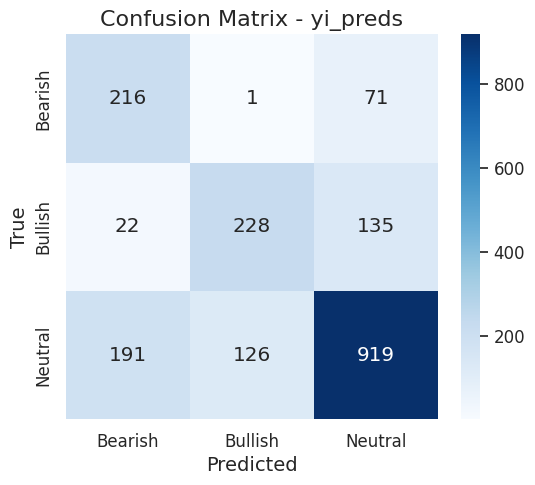


Confusion Matrix for starling_preds:


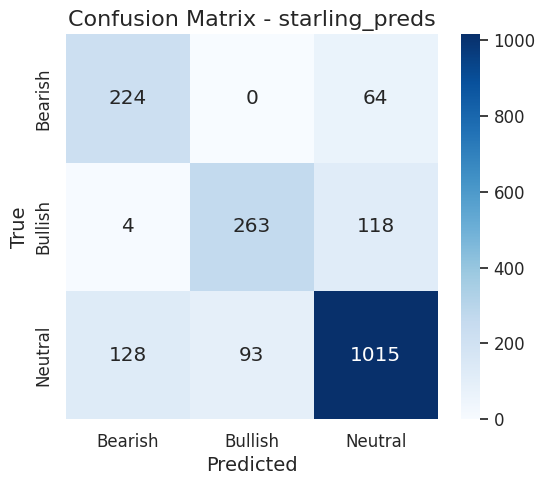

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Função para mostrar confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Bearish", "Bullish", "Neutral"], yticklabels=["Bearish", "Bullish", "Neutral"])
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Loop sobre colunas com predições
for col in train.columns:
    if col.endswith("_preds"):
        print(f"\nConfusion Matrix for {col}:")
        plot_confusion_matrix(y_true, train[col], title=col)


##### <font color = '#6495ED'> **3.6 Weighted Ensemble Voting** </font>

In [16]:
from scipy.stats import mode
from sklearn.metrics import classification_report

# Select prediction columns
prediction_cols = [col for col in train.columns if col.endswith("_preds")]

# Add more weight to specific models by duplicating their columns
weighted_cols = []
for col in prediction_cols:
    weighted_cols.append(col)
    if col in ["openchat_pred", "starlin_preds"]:  # Replace with your actual model column names
        weighted_cols.append(col)  # Add again for double vote

# Apply majority voting across weighted columns
ensemble_preds, _ = mode(train[weighted_cols].values, axis=1)

# Store predictions
train["ensemble_weighted"] = ensemble_preds.ravel()

#Evaluate performance
print("📊 Classification Report for Weighted Ensemble Voting:")
print(classification_report(train["label"], train["ensemble_weighted"], digits=3))

📊 Classification Report for Weighted Ensemble Voting:
              precision    recall  f1-score   support

           0      0.593     0.799     0.680       288
           1      0.711     0.753     0.731       385
           2      0.873     0.786     0.828      1236

    accuracy                          0.782      1909
   macro avg      0.726     0.779     0.746      1909
weighted avg      0.798     0.782     0.786      1909




 Confusion Matrix for ensemble_weighted:


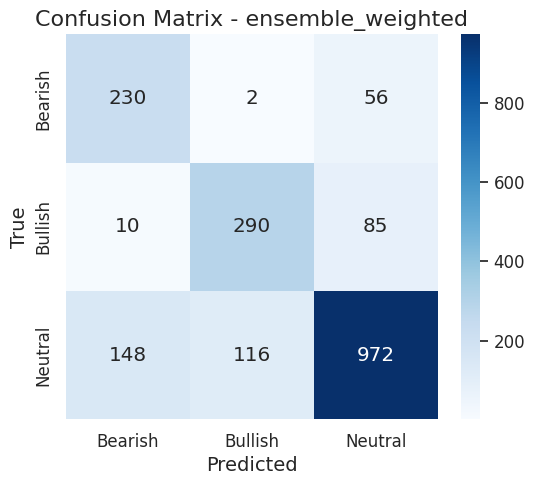

In [17]:
print(f"\n Confusion Matrix for ensemble_weighted:")
plot_confusion_matrix(y_true, train["ensemble_weighted"], title="ensemble_weighted")

##### <font color = '#6495ED'> **3.7 Ensemble relying in OpenChat and Starling** </font>

In [18]:
ensemble2_preds = []
train_no_index=train.reset_index(drop=True)
for i in range(len(train_no_index)):
    open_pred = train_no_index.loc[i, "openchat_preds"]
    star_pred = train_no_index.loc[i, "starling_preds"]

    if open_pred == 2:
        ensemble2_preds.append(2)  
    else:
        votes = [train_no_index.loc[i, col] for col in prediction_cols]
        voted_label, _ = mode(votes)
        ensemble2_preds.append(int(voted_label))

train["ensemble_open2_star01_vote"] = ensemble2_preds

print("Logical Voting Ensemble (OpenChat=2, Starling=0/1, else full vote):")
print(classification_report(train["label"], train["ensemble_open2_star01_vote"], digits=3))

Logical Voting Ensemble (OpenChat=2, Starling=0/1, else full vote):
              precision    recall  f1-score   support

           0      0.604     0.799     0.688       288
           1      0.717     0.751     0.734       385
           2      0.873     0.794     0.832      1236

    accuracy                          0.786      1909
   macro avg      0.731     0.781     0.751      1909
weighted avg      0.801     0.786     0.790      1909




 Confusion Matrix for ensemble_open2_star01_vote:


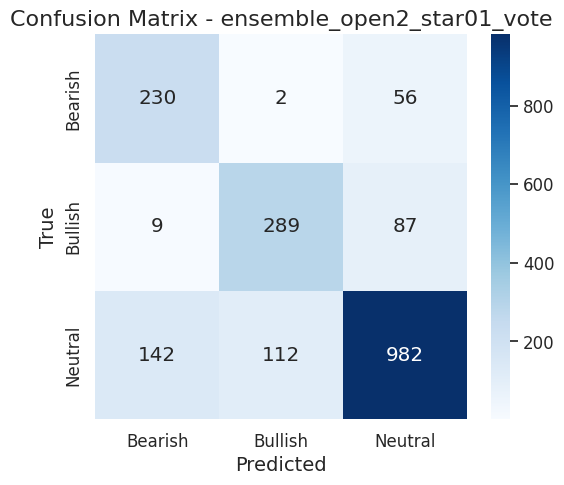

In [19]:
print(f"\n Confusion Matrix for ensemble_open2_star01_vote:")
plot_confusion_matrix(y_true, train["ensemble_open2_star01_vote"], title="ensemble_open2_star01_vote")